# Tutorial on NV centers
The goal of this tutorial is to present the physics of NV centers. We will see how they can be used for magnetometry, and see how they provide a great platform to manipulate spins at room temperature. 

## 1) Short introduction to `qutip`

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.optimize import curve_fit

# Plot settings
plt.rcParams["font.family"] = "Cambria"
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Cambria'
plt.rcParams['mathtext.it'] = 'Cambria:italic'
plt.rcParams['mathtext.bf'] = 'Cambria:bold'
plt.rcParams["font.size"] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16

`qutip` is very useful to work with quantum states and operators on python.

Let's consider a two-level system (TLS) with an excited state $\ket{e}$ and a ground state $\ket{g}$, forming a basis $\{\ket{e}, \ket{g}\}$ of a dimension 2 Hilbert space. 

 **1.1) Build the basis as qutip objects**

In [2]:
# Build the base states
e_ket = qt.basis(2, 0) # ground state
g_ket = qt.basis(2, 1) # excited state
display(g_ket) # ground state ket
display(e_ket * e_ket.dag()) # projector onto the excited state

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]

**1.2) Build the lowering and raising operators $\sigma_- = \ket{g}\bra{e}$ and $\sigma_+ = \ket{e}\bra{g}$**

**1.3) Build the Pauli matrices $\sigma_z = \sigma_+ \sigma_- - \sigma_- \sigma_+$ ; $\sigma_x = \sigma_+ + \sigma_-$ ; $\sigma_y = i (\sigma_- - \sigma_+)$**

**NB: You can also use the built-in functions `qt.spin_Jx(1/2)` or `qt.sigmax()` to build $\sigma_x$ (same for $\sigma_y, \sigma_z, \sigma_+, \sigma_-$). Just be careful with the convention that you choose for your basis (either $\{\ket{e}, \ket{g}\}$ or $\{\ket{g}, \ket{e}\}$).**

In [3]:
sigm = g_ket * e_ket.dag()
sigp = sigm.dag()
sigx = sigm + sigp
sigy = 1j * (sigm - sigp)
sigz = sigp*sigm - sigm*sigp

#Check the Pauli algebra
print(qt.commutator(sigx, sigy) == 2j*sigz, qt.commutator(sigy, sigz) == 2j*sigx, qt.commutator(sigz, sigx) == 2j*sigy)

#Compare with built-in functions
sigx_2 = 2 * qt.spin_Jx(1/2)
display(sigx_2)


True True True


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]

Consider the following Hamiltonian:
$$H = \hbar \begin{pmatrix}
\Delta  & \Omega \\
\Omega & - \Delta 
\end{pmatrix}$$

**1.4) Build it in qutip and compute (numerically) its eigenvalues and eigenstates. We will take $\hbar=1$ and $\Omega=1$. Plot the eigenenergies of $H(\Delta)$ for $\Delta$ between $-5$ and $5$** 

Text(0, 0.5, 'Energy')

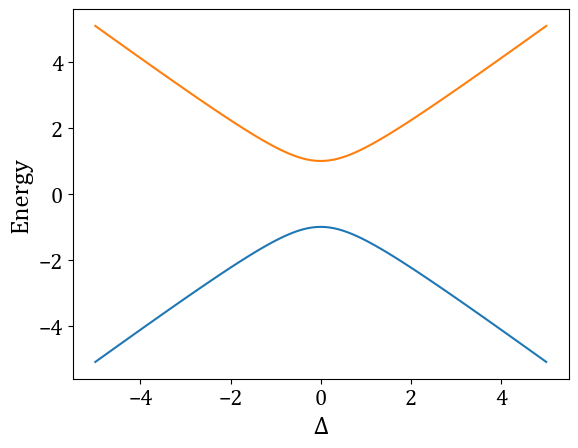

In [4]:
Omega = 1


def TestHamiltonian(Delta):
    return Delta * sigz + Omega * sigx

Delta_values = np.linspace(-5, 5, 101)
H_list = [TestHamiltonian(Delta) for Delta in Delta_values]
eigenenergy_array = np.array([H.eigenenergies() for H in H_list])

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(Delta_values, eigenenergy_array[:, 0])
ax.plot(Delta_values, eigenenergy_array[:, 1])
ax.set_xlabel(r"$\Delta$")
ax.set_ylabel(r"Energy")

**1.5) Use `qt.mesolve` to solve the evolution of the TLS under this Hamiltonian, with $\Delta = 0.4$. Take $\ket{e}$ as the initial state, and solve for $t$ between $0$ and $10$**

**1.6) Plot the expectation value of $\sigma_z$ and $\sigma_y$ as a function of time**

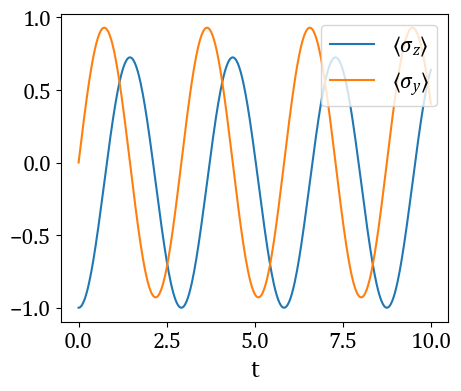

In [5]:
Delta = 0.4
H = TestHamiltonian(Delta)
times = np.linspace(0, 10, 501)
sigz_exp, sigy_exp = qt.mesolve(H, g_ket, times, e_ops=[sigz, sigy]).expect

fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111)
ax.plot(times, sigz_exp, label = r"$\langle\sigma_z\rangle$")
ax.plot(times, sigy_exp, label = r"$\langle\sigma_y\rangle$")
ax.legend(loc="upper right")
ax.set_xlabel("t")
plt.show()


## 2) NV centers
NV centers are point-like defects in a diamond lattice : two carbon atoms are replaced by a nitrogen atom, a vacancy and an additionnal electron. They are fluorescent: they emit red light ($\lambda \approx 637nm$) when excited by a green laser ($532 nm$). In the electronic ground state, we obtain a spin 1 fine structure. Under a continuous green laser excitation, NV centers are polarized in the $\ket{m_s = 0}$ state (even at room temperature), and the state $\ket{m_s = 0}$ is optically brighter than states $\ket{m_s = \pm 1}$, which provides a way to optically measure the spin state.

Fine structure Hamiltonian in the electronic ground state:
$$ \hat{H}_f = \hbar \mathcal{D}_{gs} (\hat{\vec{S}}.\vec{u}_{NV})^2 + \hbar \gamma_e \hat{\vec{S}}.\vec{B} $$

where $\hat{S}_{x,y,z}$ are dimensionless spin 1 operators such that $[S_k, S_l] = \epsilon_{klm} i S_m$.

Here, $\vec{u}_{NV}$ is the N-V axis, which defines a preferential quantization axis.

**2.1) Build the $\hat{S}_{x,y,z}$ operators (using `qutip` built-in functions)**

**2.2) Build a function that returns H for any given magnetic field $\vec{B}$ and any direction $\vec{u}_{NV}$** 

In [6]:
Sx, Sy, Sz = qt.spin_J_set(1)

In [7]:
# Define constants
D = 2870 # MHz
gamma_e = 2.8 # MHz/G

def generate_Hf(B_vec, u_vec):
    Bx, By, Bz = B_vec
    ux, uy, uz = u_vec

    H = D * (Sx*ux + Sy*uy + Sz*uz)**2 + gamma_e * (Bx*Sx + By*Sy + Bz*Sz)
    return H

**2.3) Set $\vec{u}_{NV} = \vec{u}_z$. Consider $\vec{B} = B_1 \vec{u}_z$ and plot the eigenenergies of the system for $B_1$ between $0$ and $1100G$. Do the same for $\vec{B} = B_1 \vec{u}_x$ and $\vec{B} = B_0 \vec{u}_z + B_1 \vec{u}_x$, with $B_0 = 100G$.**

**2.4) What component of $\vec{B}$ has the dominant effect?** 

Text(0, 0.5, 'Energy (MHz)')

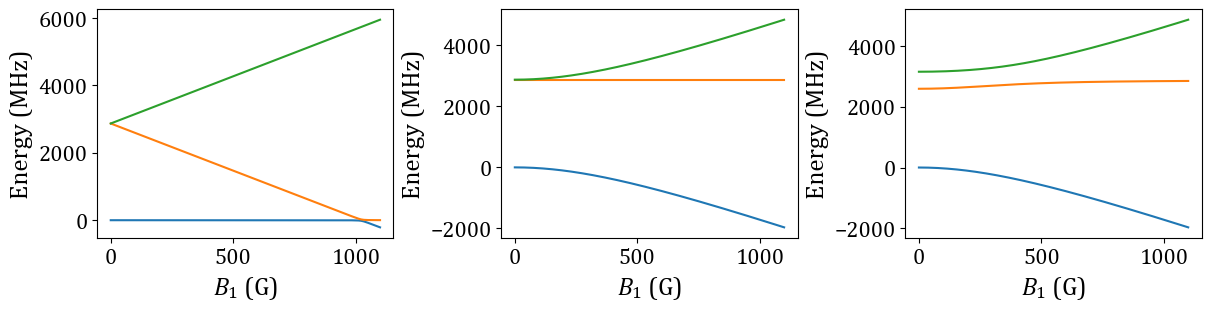

In [8]:
%matplotlib widget
%matplotlib inline
plt.close("all")
B0 = 100
B1min, B1max = 0, 1100
B1_array = np.linspace(B1min, B1max, 201)

eigvals_a = []
eigvals_b = []
eigvals_c = []

uz = np.array([0.,0,1]) # = u_NV
ux = np.array([1,0,0])

for B1 in B1_array:
    B_a = B1 * uz + 10 * ux
    B_b = B1 * ux
    B_c = B0 * uz + B1 * ux
    H_a = generate_Hf(B_a, uz)
    H_b = generate_Hf(B_b, uz)
    H_c = generate_Hf(B_c, uz)

    eigvals_a.append(H_a.eigenenergies())
    eigvals_b.append(H_b.eigenenergies())
    eigvals_c.append(H_c.eigenenergies())

eigvals_a = np.array(eigvals_a)
eigvals_b = np.array(eigvals_b)
eigvals_c = np.array(eigvals_c)

fig = plt.figure(figsize=(12,3), constrained_layout=True)
ax = fig.add_subplot(131)
ax.plot(B1_array, eigvals_a)
ax.set_xlabel("$B_1$ (G)")
ax.set_ylabel("Energy (MHz)")

ax = fig.add_subplot(132)
ax.plot(B1_array, eigvals_b)
ax.set_xlabel("$B_1$ (G)")
ax.set_ylabel("Energy (MHz)")

ax = fig.add_subplot(133)
ax.plot(B1_array, eigvals_c)
ax.set_xlabel("$B_1$ (G)")
ax.set_ylabel("Energy (MHz)")




*Answer: The dominant effect comes from $B_z$. Other field components act as a perturbation on the Hamiltonian (1st order on the state, 2nd order on the energy).*

### NV centers as magnetic field sensors
We will now look at experimental data obtained on a dense ensemble of NV centers ($\sim 10$ ppm). The sample is continuously exposed to a green laser. A microwave antenna is placed close to the sample, and we do a frequency scan of the microwave (from 2 to 4 GHz for example). For each value of f, we measure the fluorescent light. This is often called "Optically Detected Magnetic Resonance" (ODMR).

In a diamond lattice, there are 4 possible orientations for N-V axes. In an ensemble of NV centers, each possible direction corresponds to a class of NV centers (A,B,C,D). For a given ODMR signal, we will name the NV classes according to the projection of the magnetic field on the NV axis. Class A corresponds to the highest value and class D to the lowest value. 

**2.5) Let's now plot the ODMR signal from experimental data files `data_01.txt` and `data_02.txt`. Why do we see dips in the intensity of the fluorescent light?**

**2.6) What can you say about the orientation of the magnetic field relative to the NV axes in these experiments? (qualitatively)** 

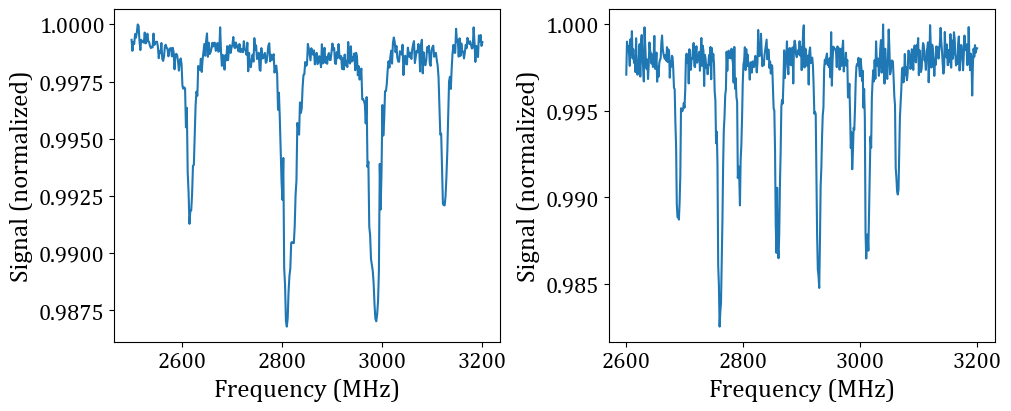

In [9]:
data1 = np.loadtxt("NV_data\\data_01.txt")
freqs1, signal1 = data1[:,0], data1[:,1] # The signal is the intensity of the fluorescent light, normalized to its maximum value

data2 = np.loadtxt("NV_data\\data_02.txt")
freqs2, signal2 = data2[:,0], data2[:,1]

fig = plt.figure(figsize=(10,4), layout="constrained")
ax = fig.add_subplot(121)
ax.plot(freqs1, signal1)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (normalized)")

ax= fig.add_subplot(122)
ax.plot(freqs2, signal2)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (normalized)")

plt.show()

- *The dips corresponds to microwave resonances of the electronic spin. When we excite a transition between $\ket{m_s = 0}$ and $\ket{m_s = \pm 1}$, the concerned NV centers become less bright*
- *On the first dataset we can only distinguish two classes (# peaks / 2). We can distinguish all 4 classes on the second dataset. The first set corresponds to a situation where the magnetic field is aligned with one class of NV, causing the 3 other classes to be degenerate. The second set corresponds to a more general situation, where the projection of the field on the NV axis is different for all four classes of NV centers.*

*Changes : use a for loop, use the better H definition, fit the data to find the best B?*

**2.7) Estimate the magnetic field applied to the sample in the `data_01` measurement. Check consistency by computing the eigenvalues of the Hamiltonian for the different classes given this magnetic field.**

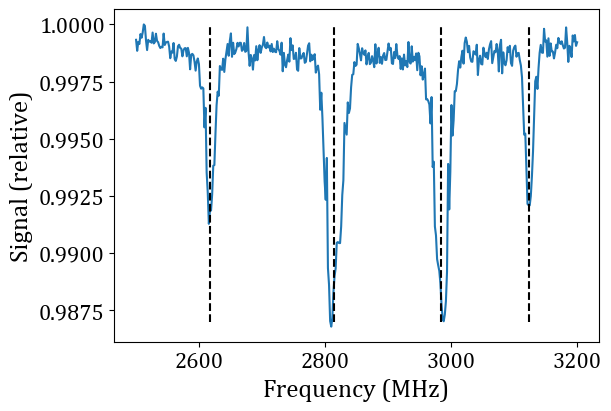

In [10]:
#%matplotlib widget
%matplotlib inline
f1 = 2617
f4 = 3123
f2 = 2814
f3 = 2984
frequencies = [f1, f2, f3, f4]
delta_f1 = 5 #Rough estimate of the uncertainty on f1 and f4
delta_f2 = 10 #Rough estimate of the uncertainty on f2 and f3
plt.close('all')
fig = plt.figure(figsize=(6,4), layout="constrained")
ax = fig.add_subplot(111)
ax.plot(freqs1, signal1)
for f in frequencies:
    ax.plot([f, f], [0.987, 1], color='black', linestyle = '--')
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (relative)")
plt.show()

In [11]:
# Class A
D_mes = (f1 + f4) / 2
B_mes = (f4 - f1) / (2 * gamma_e)
delta_B = delta_f1 / (2 * gamma_e)
print(rf"We measure D = {D_mes:.0f} +/- {delta_f1} MHz,", rf"B = {B_mes:.1f} +/- {delta_B:.1f}G")

# Class B(CD)
D_mes2 = (f3 + f2) / 2
B_mes2 = (f3 - f2) / (2 * gamma_e)
delta_B2 = delta_f2 / (2 * gamma_e)
print(rf"We measure D = {D_mes2:.0f} +/- {delta_f2} MHz,", rf"B = {B_mes2:.1f} +/- {delta_B2:.1f}G")


We measure D = 2870 +/- 5 MHz, B = 90.4 +/- 0.9G
We measure D = 2899 +/- 10 MHz, B = 30.4 +/- 1.8G


*Answer: For class A, we measure $|B_z| = 90.4 \pm 0.9 G$. For class B(CD), we measure $|B_z| = 30.4 \pm 1.8 G$. Class A allows for a precise measurement of $D$. The transverse field makes the measure of D more tricky when we consider other classes.* 

In [12]:
B1 = B_mes * np.array([0,0,1]) # class A
B2 = B_mes * np.array([2*np.sqrt(2)/3, 0, -1/3])# class B (classes C and D will have the same field up to a rotation of +/- 120°)

H1 = generate_Hf(B1, uz)
eigvals_1 = H1.eigenenergies()
print(eigvals_1)

H2 = generate_Hf(B2, uz)
eigvals_2 = H2.eigenenergies()
eigvals_2 -= eigvals_2[0]
print(eigvals_2)

[   0. 2617. 3123.]
[   0.         2814.93854679 2984.18032281]


*We recover consistent values for the eigenenergies of classes BCD with the field measured on class A.*

**2.8) Bonus question : Find a magnetic field vector that fits the `data_02.txt` dataset.**

In [13]:
# You can use the following convention for the 4 N-V axes:
n1 = np.array([1, 1, 1])/np.sqrt(3)
n2 = np.array([1, -1, -1])/np.sqrt(3)
n3 = np.array([-1, 1, -1])/np.sqrt(3)
n4 = np.array([-1, -1, 1])/np.sqrt(3)

n_array = np.array([n1,n2,n3,n4])

Estimated magnetic field projections from the ODMR spectrum: 67.14285714285715 45.0 34.464285714285715 12.678571428571429


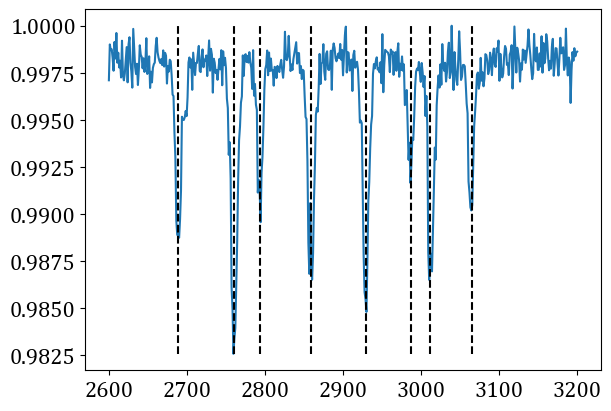

In [14]:
plt.close('all')
f1 = 2689
f2 = 2760
f3 = 2794
f4 = 2859
f5 = 2930
f6 = 2987
f7 = 3012
f8 = 3065
frequencies = [f1, f2, f3, f4, f5, f6, f7, f8]
vmin = np.min(signal2)
fig = plt.figure(figsize=(6,4), layout="constrained")
ax = fig.add_subplot(111)
ax.plot(freqs2, signal2)
for f in frequencies:
    ax.plot([f, f], [vmin, 1], linestyle="--", color = "black")

B1 = (f8 - f1)/(2*gamma_e)
B2 = (f7 - f2)/(2*gamma_e)
B3 = (f6 - f3)/(2*gamma_e)
B4 = (f5 - f4)/(2*gamma_e)

print("Estimated magnetic field projections from the ODMR spectrum:", B1, B2, B3, B4)

*We now have the absolute values of $B_1, B_2, B_3, B_4$. We don't know the global sign, so let's assume $B_1>0$. This forces $B_2 < 0$ and $B_3 <0$. There remains an uncertainty on the sign of $B_4$.*

In [15]:
basis_norm = (n_array.T@n_array)[0,0]
Btot1 = (B1*n1 - B2*n2 - B3*n3 - B4*n4) / basis_norm

Btot2 = (B1*n1 - B2*n2 - B3*n3 + B4*n4) / basis_norm

print(Btot1@n1.T, Btot1@n2.T, Btot1@n3.T, Btot1@n4.T)

print(Btot2@n1.T, Btot2@n2.T, Btot2@n3.T, Btot2@n4.T)
print(B1, B2, B3, B4)

73.39285714285715 -38.75 -28.214285714285722 -6.428571428571431
67.05357142857144 -45.08928571428572 -34.55357142857143 12.589285714285712
67.14285714285715 45.0 34.464285714285715 12.678571428571429


*Only $\frac{3}{4}(B_1 \vec{n_1} - B_2 \vec{n_2} - B_3 \vec{n_3} + B_4 \vec{n_4})$ is compatible with our measurements*

In [16]:
H1 = generate_Hf(Btot2, n1)
eigenenergies_1, _ = H1.eigenstates()
eigenenergies_1 -= eigenenergies_1[0]
print(np.round(eigenenergies_1[1:]), f1, f8)

H2 = generate_Hf(Btot2, n2)
eigenenergies_2, _ = H2.eigenstates()
eigenenergies_2 -= eigenenergies_2[0]
print(np.round(eigenenergies_2[1:]), f2, f7)

H3 = generate_Hf(Btot2, n3)
eigenenergies_3, _ = H3.eigenstates()
eigenenergies_3 -= eigenenergies_3[0]
print(np.round(eigenenergies_3[1:]), f3, f6)

H4 = generate_Hf(Btot2, n4)
eigenenergies_4, _ = H4.eigenstates()
eigenenergies_4 -= eigenenergies_4[0]
print(np.round(eigenenergies_4[1:], 0), f4, f5)



[2688. 3063.] 2689 3065
[2760. 3012.] 2760 3012
[2793. 2986.] 2794 2987
[2857. 2929.] 2859 2930


In [17]:
# We could also implement a simple optimization algorithm to find a matching magnetic field vector. 
ux, uy, uz = np.identity(3)

B_guess = B1*n1 #initial guess

N_loop = 500 #number of loops for the gradient descent
lr = 20 #amplitude of the magnetic field update at each loop
lr_rate = 0.99 #multiplying factor of lr at each loop
dB = 2
measured_frequency_array = np.array([[f1, f8], [f2, f7], [f3, f6], [f4, f5]])

def loss_function(B_guess):
    H_list = [generate_Hf(B_guess, n) for n in n_array]
    transition_frequency_array= np.array([(H.eigenenergies()[1:] - H.eigenenergies()[0]) for H in H_list])
    return np.linalg.norm(transition_frequency_array-measured_frequency_array)

losses=[loss_function(B_guess)]
grad = np.zeros(3)
for n in range(N_loop):
    grad[0] = loss_function(B_guess + dB/2 * ux) - loss_function(B_guess - dB/2 * ux)
    grad[1] = loss_function(B_guess + dB/2 * uy) - loss_function(B_guess - dB/2 * uy)
    grad[2] = loss_function(B_guess + dB/2 * uz) - loss_function(B_guess - dB/2 * uz)
    grad = grad/np.linalg.norm(grad)
    B_guess = B_guess - grad * lr
    losses.append(loss_function(B_guess))
    lr = lr*lr_rate
print(B_guess, Btot2)

[19.14761853 28.36653236 69.0122559 ] [19.0216294  28.14582562 68.97273752]


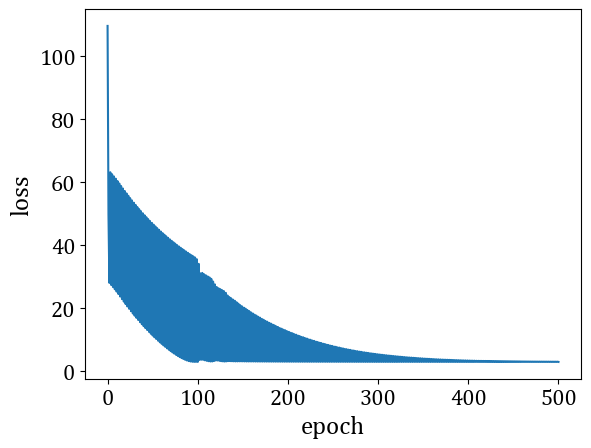

In [18]:
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

*Note that it is impossible to fully determine the magnetic field vector from an ODMR measurement alone. For example, we can't differentiate between $\vec{B}$ and $- \vec{B}$.*

### NV centers as controllable spins

Thanks to the cristalline structure of diamond, NV center spins are quite well isolated from the environment (for a solid state system). This allows for coherent control of the electronic spin, even at room temperature. Let's consider an effective two level-system, for example formed by the pair ($\ket{m_s = 0}$, $\ket{m_s = +1}$). We need to take into account decoherence, which leads to the introduction of two characteristic durations $T_1$ and $T_2$, that answer two distinct questions:

- $T_1$ is the characteristic relaxation time: if I put my spin in $\ket{m_s = +1}$, how long does it take for it to go back to $\ket{m_s = 0}$ (or to thermal equilibrium)? 
- $T_2$ is the characteristic coherence time: if I put my spin in a coherent superposition of $\ket{m_s = 0}$ and $\ket{m_s = +1}$, for how long is the phase of the superposition preserved?

We also need to introduce the effective coherence time $T_2^*$. Indeed, our sample is subject to magnetic field inhomogeneities, which cause a fast decoherence between different electronic spins. However, performing a bit-flip (or $\pi$-pulse) on the sample reverses the effect of these stable inhomogeneities. This gives us access to the "true" coherence time $T_2$.

Experimental protocol: we place our sample in a magnetic field, aligned with one NV axis (see `data_01`) to have well defined spin states. The sample is polarized in $\ket{m_s = 0}$ by a long green laser pulse. The laser is turned off and a microwave pulse of duration $t$ is sent on the sample. The microwave frequency is chosen to fit the transition $\ket{m_s = 0}$ → $\ket{m_s = +1}$ of class A. A short laser pulse is then sent to measure the fluorescence of the sample. We repeat this and scan the value of $t$. 


**2.9) Plot the experimental data from `data_03.txt`. What do you see?**

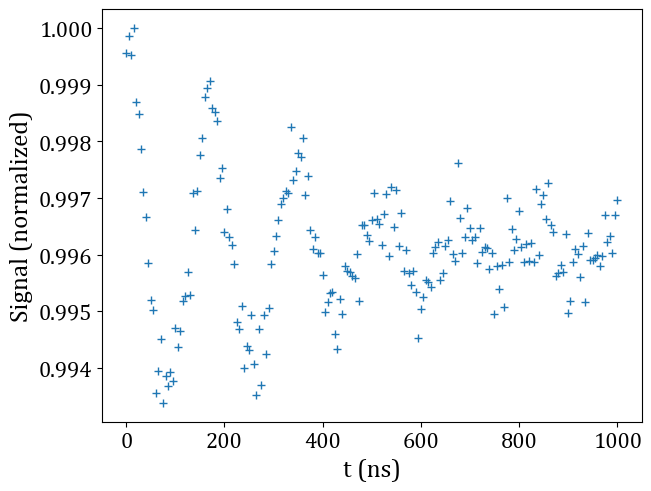

In [31]:
data3 = np.loadtxt("NV_data\\data_03.txt")
t3, s3 = data3[:,0], data3[:,1] # time in ns, signal normalized to its maximum value

plt.close('all')
%matplotlib inline
# %matplotlib widget
fig = plt.figure(layout="constrained")
ax = fig.add_subplot(111)
ax.plot(t3, s3, '+')
ax.set_xlabel("t (ns)")
ax.set_ylabel("Signal (normalized)")
plt.show()

*We observe Rabi oscillations between $\ket{m_s = 0}$ and $\ket{m_s = +1}$. The amplitude of the oscillations decays because of decoherence.*

**2.10) Estimate the length of a $\pi$-pulse in these experimental conditions.**

*Around 75ns*

We now consider another experimental protocol. A long laser pulse in applied on the sample. A $\pi$-pulse and a $\pi/2$-pulse (microwave) are applied to the sample. We wait a time $\Delta t$. A second $\pi/2$-pulse is applied, and we measure the fluorescence with a short laser pulse. We repeat for different values of $\Delta t$. 

**2.11) Plot the experimental data. What quantity can we extract from it?**

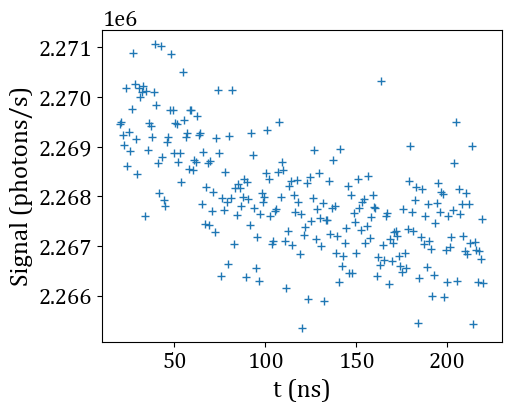

In [20]:
plt.close('all')
%matplotlib inline

data4 = np.loadtxt("NV_data\\data_04.txt")
t4 = data4[:,0] # delta t in ns
s4 = data4[:,1] # signal in photons/s


fig = plt.figure(figsize=(5,4), layout='constrained')
ax = fig.add_subplot(111)
ax.plot(t4, s4, "+")
ax.set_xlabel("t (ns)")
ax.set_ylabel("Signal (photons/s)")

plt.show()

*This is a Ramsey interferometry measurement. We can extract the effective coherence time $T_2^*$.*

**2.12) Fit the experimental data to estimate said quantity.**

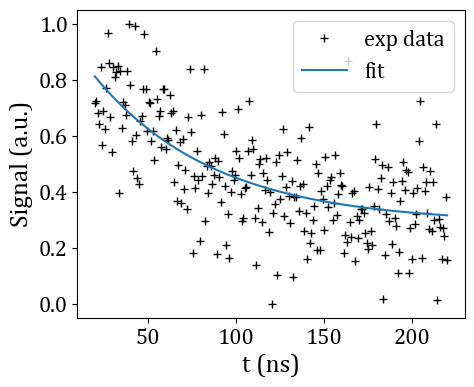

[68.23237915  0.7026083   0.2876914 ] [2.16741180e+02 3.60066595e-03 1.27424490e-03]
Estimated T2* : 68 +/- 15 ns


In [21]:
sfit = s4
sfit = sfit - np.min(sfit)
sfit = sfit / np.max(np.abs(sfit))

def ramsey(t, T2s, A, B):
    return A * np.exp(-t/T2s) + B

p0 = [60, 0.7, 0.2]

popt, pcov = curve_fit(ramsey, t4, sfit, p0)

fig = plt.figure(figsize = (5,4))
ax = fig.add_subplot(111)
ax.plot(t4, sfit, "k+", label = "exp data")
#ax.plot(t4, ramsey(t4, *p0))
ax.plot(t4, ramsey(t4, *popt), label="fit")
ax.legend()
ax.set_xlabel("t (ns)")
ax.set_ylabel("Signal (a.u.)")
plt.show()
print(popt, np.diag(pcov))
print(rf"Estimated T2* : {popt[0]:.0f} +/- {np.sqrt(pcov[0,0]):.0f} ns")

*We obtain $T_2^* = 68 \pm 15$ ns. This is consistent with the bandwith observed on the ODMR spectrum ($\sim 10$ MHz).*

We will now look at a spin-echo measurement. After a long laser pulse, we send a $\pi/2$ pulse on the sample. After a duration $\Delta t/2$, we send a $\pi$-pulse. After another $\Delta t /2$, we send a $\pi/2$-pulse and measure the fluorescence with a short laser pulse. The intermediate $\pi$ pulse removes the decoherence caused by static inhomogeneities of the magnetic field. 

**2.13) Plot the experimental data. What quantity can we extract from this measurement?**

**2.14) Fit the experimental data to estimate said quantity.**

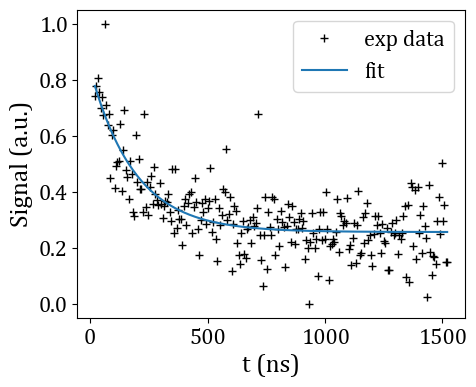

[188.77872208   0.58024441   0.25603088] [4.10002343e+02 1.56039065e-03 6.75918873e-05]
Estimated T2 : 189 +/- 20 ns


In [22]:
data5 = np.loadtxt("NV_data\\data_05.txt")
t5, s5 = data5.T
s5 = s5 - np.min(s5)
s5 = s5 / np.max(s5)

def echo(t, T2, A, B):
    return A * np.exp(-t/T2) + B

p0 = [200, 0.8, 0.2]
popt, pcov = curve_fit(echo, t5, s5, p0)
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111)
ax.plot(t5, s5, "k+", label="exp data")
#ax.plot(t5, echo(t5, *p0))
ax.plot(t5, echo(t5, *popt), label="fit")
ax.legend()
ax.set_xlabel("t (ns)")
ax.set_ylabel("Signal (a.u.)")
plt.show()
print(popt, np.diag(pcov))

print(rf"Estimated T2 : {popt[0]:.0f} +/- {np.sqrt(pcov[0,0]):.0f} ns")

*The spin-echo sequence allows to measure $T_2$, the "true" coherence time. We obtain $T_2 = 189 \pm 20ns$. This is around 3 times higher than the value for $T_2^*$, which shows that field inhomogeneities play a significant role in the decoherence of the ensemble of spins.*

### 3) Hyperfine structure of the NV center
$^{14}N$ atoms have a nuclear spin of $1$ that couples to the electronic spin. This adds a hyperfine structure on top of the already described fine structure. Assuming a magnetic field along the N-V ($z$) axis, we obtain the following (approximate) Hamiltonian:
$$ \hat{H} = \hat{H}_f + \hat{H}_{hf}$$
$$ \hat{H}_{hf} = - \hbar \mathcal{Q}_N \hat{I}_z^2 - \hbar \gamma_N B \hat{I}_z - \hbar \mathcal{A}_{zz} \hat{I}_z \hat{S}_z$$
Where $\hat{I}_z$ is a nuclear spin operator. We give $\gamma_N = 0.31$ kHz/G. $\mathcal{A}_{zz}$ and $\mathcal{Q}_N$ are in the MHz range. 

**3.1) Why didn't we observe this hyperfine structure in previous experimental data?**

`data_06` is ODMR experimental data from a much purer diamond sample. It corresponds to the transition $\ket{m_s=0, m_I}$ to $\ket{m_s=-1, m_I}$.

**3.2) What do you notice?**

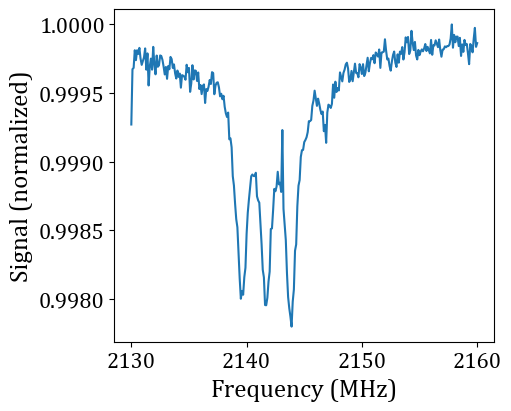

In [23]:
data6 = np.loadtxt("NV_data\\data_06.txt")
freqs6 = data6[:,0]
s6 = data6[:,1]

plt.close('all')
fig = plt.figure(figsize=(5,4), layout="constrained")
ax = fig.add_subplot(111)
ax.plot(freqs6, s6)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (normalized)")
plt.show()

*We notice that the resonance is split in three, which is coherent with the hyperfine coupling describe above. We can also notice what looks like a small dip on the right of the main 3 peaks, which could be due to the coupling of the electronic spin to another type of nuclear spin, such as the spin of $^{13}C$ nuclei that can be found in small amounts in diamond.*

For a magnetic field of around $500$ G, the nuclear spin is slightly polarized in the state $\ket{m_I = +1}$ by the green laser driving, and the state $\ket{m_s=0, m_I=+1}$ is brighter than the others. This allows us to perform a direct measurement of the nuclear spin transitions, by ODNMR (the N stands for nuclear). We use the same protocol for ODMR and ODNMR, except that we excite the sample with radio waves.

**3.3) Plot the ODNMR signal from `data_07.txt`. Identify the nuclear transitions and estimate the values of $B$, $\mathcal{A}_{zz}$ and $\mathcal{Q}_N$. We assume $\mathcal{Q}_N > \mathcal{A}_{zz} + \gamma_N B$.**

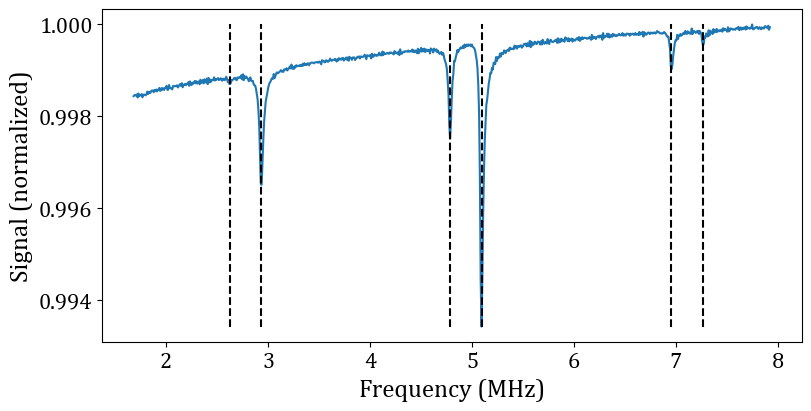

In [24]:
plt.close("all")
#%matplotlib widget
%matplotlib inline
data7 = np.loadtxt("NV_data\\data_07.txt")
freqs7, s7 = data7.T

f1 = 2.624
f2 = 2.932
f3 = 4.784
f4 = 5.093
f5 = 6.956
f6 = 7.267
frequencies = [f1, f2, f3, f4, f5, f6]
vmin = np.min(s7)
fig = plt.figure(figsize=(8,4), layout="constrained")
ax = fig.add_subplot(111)
ax.plot(freqs7, s7, "-")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Signal (normalized)")
for f in frequencies:
    ax.plot([f, f], [vmin, 1], "k--")
plt.show()

*Answer*

We can associate each signal dip with a nuclear transition. For example $f_4$ corresponds to the transiton $\ket{m_s=0, m_I=0} \leftrightarrow \ket{m_s=0, m_I=+1}$.
We have the following relations:
$$2\gamma_n B = f_2 - f_1 = f_4 - f_3 = f_6 - f_5$$
$$\mathcal{Q}_N = \frac{f_1 + f_6}{2} = \frac{f_2 + f_5}{2} = \frac{f_3 + f_4}{2}$$
$$\mathcal{A}_{zz} = f_5 - f_3 = f_4 - f_2 = f_6 - f_4 = f_3 - f_1$$

**NB:** We observe that we have a bandwidth of the order of a few kHz, which means that we have an effective coherence time $T_2^*$ of the order of 1 ms !

In [25]:
gamma_n = 0.31e-3 #MHz/G
B_array = np.array([f2-f1, f4-f3, f6-f5]) / (2 * gamma_n)
B = np.mean(B_array)
B_sigma = np.sqrt(np.sum((B_array - B)**2)/2)
print(rf"B = {B:.1f} +/- {B_sigma:.1f} G")

Qn_array = np.array([f1 + f6, f2 + f5, f3 + f4])/2
Qn = np.mean(Qn_array)
Qn_sigma = np.sqrt(np.sum((Qn_array - Qn)**2)/2)
print(rf"Qn = {Qn:.3f} +/- {Qn_sigma:.3f} MHz")

Azz_array = np.array([f5 - f3, f4 - f2, f3 - f1])
Azz = np.mean(Azz_array)
Azz_sigma = np.sqrt(np.sum((Azz_array - Azz)**2)/2)

print(rf"Azz = {Azz:.3f} +/- {Azz_sigma:.3f} MHz")


B = 498.9 +/- 2.5 G
Qn = 4.943 +/- 0.004 MHz
Azz = 2.164 +/- 0.007 MHz


One can then similarly manipulate the nuclear spin. `data_08.txt` is experimental data from a Rabi oscillation measurement, where we excite the sample with a radio wave set to 509 kHz. Note that the time is expressed in ms. 

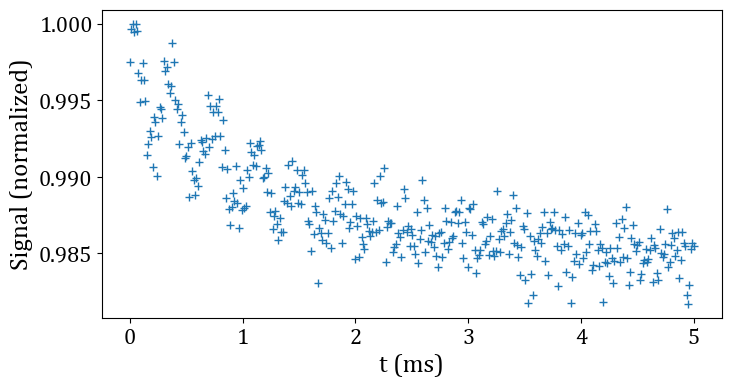

In [26]:
data8 = np.loadtxt("NV_data\\data_08.txt")
t8, s8 = data8[:,0], data8[:,1] # time in ns, signal normalized to its maximum value

plt.close('all')
%matplotlib inline
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.plot(t8, s8, "+")
ax.set_xlabel("t (ms)")
ax.set_ylabel("Signal (normalized)")
plt.show()